In [3]:
!pip install -q ultralytics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 18.9 MB/s eta 0:00:00a 0:00:01


In [2]:
from ultralytics import YOLO

# model load
model = YOLO("/kaggle/input/datasets/garambharadhi/trained-model/train_results/weights/best.pt")

# validation run
metrics = model.val(
    data="/kaggle/input/datasets/garambharadhi/major-project/data.yaml",
    imgsz=832,
    batch=8,
    device=0,
    workers=2,
    save_json=True,
    plots=True,
    project="/kaggle/working/results",
    name="val_results"
)

# ===== METRICS PRINT =====
print("\n🔥 ===== VALIDATION METRICS ===== 🔥")

print(f"mAP50-95 : {metrics.box.map:.4f}")
print(f"mAP50    : {metrics.box.map50:.4f}")
print(f"mAP75    : {metrics.box.map75:.4f}")

print(f"Precision: {metrics.box.mp:.4f}")
print(f"Recall   : {metrics.box.mr:.4f}")

print("\n📊 Per-class mAP:")
for i, cls_map in enumerate(metrics.box.maps):
    print(f"Class {i} mAP50-95: {cls_map:.4f}")

print("\n✅ Done!")

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Ultralytics 8.4.37 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 73 layers, 11,126,358 parameters, 0 gradients, 28.4 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 10.7±5.4 MB/s, size: 32.1 KB)
val: Scanning /kaggle/input/datasets/garambharadhi/major-project/valid/labels... 1323 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 1323/1323 261.8it/s 5.1s0.1s
WARNING ⚠️ val: Cache directory /kaggle/input/datasets/garambharadhi/major-project/valid is not writable, cache not saved.
WARNING ⚠️ Box and segment counts should be equal, but got len(segments) = 1, len(boxes) = 1578. To resolve this only boxes will be used and all segments 

In [3]:
from ultralytics import YOLO

# Load trained model
model = YOLO("/kaggle/input/datasets/garambharadhi/trained-model/train_results/weights/best.pt")

# Source folder: yahan apna test images / video path do
source_path = "/kaggle/input/datasets/garambharadhi/major-project/test/images"

# Prediction
results = model.predict(
    source=source_path,
    imgsz=832,          # same as training
    conf=0.55,          # stricter threshold -> fewer false positives
    iou=0.50,           # normal NMS IoU
    device=0,
    save=True,
    save_txt=True,
    save_conf=True,
    show_labels=True,
    show_conf=True,
    project="/kaggle/working/results",
    name="predict_results",
    agnostic_nms=False,
    max_det=20,
    stream=False
)

print("\n✅ Prediction done!")
print("Saved at: /kaggle/working/results/predict_results")


image 1/669 /kaggle/input/datasets/garambharadhi/major-project/test/images/-E3-83-80-E3-82-A6-E3-83-B3-E3-83-AD-E3-83-BC-E3-83-89-20-9-_jpeg.rf.506fded463c87d1c86b98a4335ed6384.jpg: 832x832 1 Bird, 25.2ms
image 2/669 /kaggle/input/datasets/garambharadhi/major-project/test/images/0014_jpg.rf.df4f71be40c0f574a567c1c0e9f23d5f.jpg: 832x832 1 Drone, 25.2ms
image 3/669 /kaggle/input/datasets/garambharadhi/major-project/test/images/0026_jpg.rf.3972f44e2ed429a84417a5d20a98609d.jpg: 832x832 1 Drone, 25.2ms
image 4/669 /kaggle/input/datasets/garambharadhi/major-project/test/images/0034_jpg.rf.e37badcff6fe0bdbb97a1b852e0d9feb.jpg: 832x832 1 Drone, 25.2ms
image 5/669 /kaggle/input/datasets/garambharadhi/major-project/test/images/0039_jpg.rf.7a3f05eca7d5af54fc2893505dc06815.jpg: 832x832 2 Drones, 25.2ms
image 6/669 /kaggle/input/datasets/garambharadhi/major-project/test/images/0046_jpg.rf.c5f42dbad2c02217da20896e7e61792d.jpg: 832x832 (no detections), 25.2ms
image 7/669 /kaggle/input/datasets/garam

In [4]:
# import shutil

# # source folder (prediction results)
# folder_path = "/kaggle/working/results/predict_results"

# # zip file ka naam
# zip_path = "/kaggle/working/predict_results.zip"

# # zip create
# shutil.make_archive(zip_path.replace(".zip",""), 'zip', folder_path)

# print("✅ ZIP created at:", zip_path)

✅ ZIP created at: /kaggle/working/predict_results.zip


In [5]:
# import shutil

# # parent folder jisme sab hai (train + val + predict)
# source_folder = "/kaggle/working/results"

# # final zip path
# zip_path = "/kaggle/working/val_predict_results.zip"

# # zip create
# shutil.make_archive(zip_path.replace(".zip",""), 'zip', source_folder)

# print("✅ Full Results ZIP created!")
# print("📥 Path:", zip_path)

✅ Full Results ZIP created!
📥 Path: /kaggle/working/val_predict_results.zip


In [5]:
from ultralytics import YOLO

model = YOLO("/kaggle/input/datasets/garambharadhi/trained-model/train_results/weights/best.pt")

results = model.predict(
    source="/kaggle/input/datasets/garambharadhi/major-project/test/images",
    imgsz=832,
    conf=0.55,
    iou=0.40,
    max_det=8,
    device=0,
    save=True,
    save_txt=True,
    save_conf=True,
    show_labels=True,
    show_conf=True,
    project="/kaggle/working/results",
    name="predict_results_last",
    agnostic_nms=False,
    stream=False,
    exist_ok=True
)

print("Done")
print("/kaggle/working/results/predict_results_last")


image 1/669 /kaggle/input/datasets/garambharadhi/major-project/test/images/-E3-83-80-E3-82-A6-E3-83-B3-E3-83-AD-E3-83-BC-E3-83-89-20-9-_jpeg.rf.506fded463c87d1c86b98a4335ed6384.jpg: 832x832 1 Bird, 25.3ms
image 2/669 /kaggle/input/datasets/garambharadhi/major-project/test/images/0014_jpg.rf.df4f71be40c0f574a567c1c0e9f23d5f.jpg: 832x832 1 Drone, 25.8ms
image 3/669 /kaggle/input/datasets/garambharadhi/major-project/test/images/0026_jpg.rf.3972f44e2ed429a84417a5d20a98609d.jpg: 832x832 1 Drone, 25.5ms
image 4/669 /kaggle/input/datasets/garambharadhi/major-project/test/images/0034_jpg.rf.e37badcff6fe0bdbb97a1b852e0d9feb.jpg: 832x832 1 Drone, 25.2ms
image 5/669 /kaggle/input/datasets/garambharadhi/major-project/test/images/0039_jpg.rf.7a3f05eca7d5af54fc2893505dc06815.jpg: 832x832 2 Drones, 25.2ms
image 6/669 /kaggle/input/datasets/garambharadhi/major-project/test/images/0046_jpg.rf.c5f42dbad2c02217da20896e7e61792d.jpg: 832x832 (no detections), 25.2ms
image 7/669 /kaggle/input/datasets/garam

In [6]:
# import shutil

# # final prediction folder
# folder_path = "/kaggle/working/results/predict_results_last"

# # zip path
# zip_path = "/kaggle/working/final_prediction_results.zip"

# # create zip
# shutil.make_archive(zip_path.replace(".zip",""), 'zip', folder_path)

# print("✅ ZIP created!")
# print("📂 Path:", zip_path)

✅ ZIP created!
📂 Path: /kaggle/working/final_prediction_results.zip



image 1/1 /kaggle/input/datasets/garambharadhi/major-project/test/images/0046_jpg.rf.c5f42dbad2c02217da20896e7e61792d.jpg: 832x832 1 Drone, 25.3ms
Speed: 4.7ms preprocess, 25.3ms inference, 1.6ms postprocess per image at shape (1, 3, 832, 832)
Results saved to /kaggle/working/results/one_image_test
Done
/kaggle/working/results/one_image_test


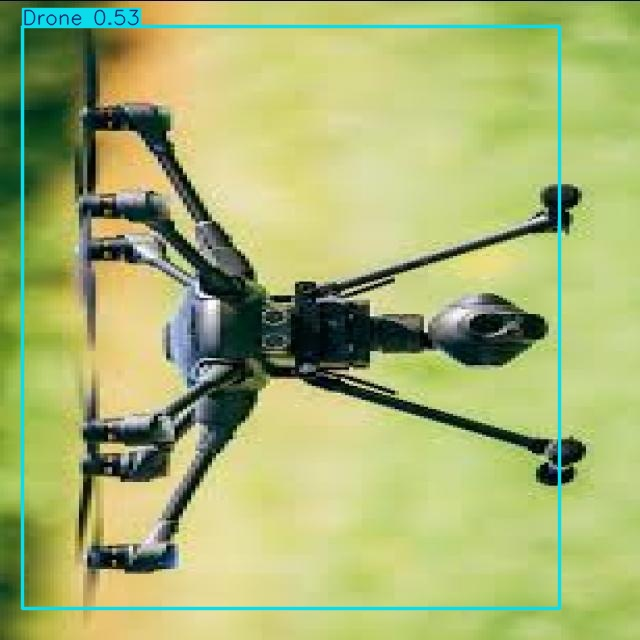

In [7]:
# from ultralytics import YOLO
# from PIL import Image
# from IPython.display import display

# # model load
# model = YOLO("/kaggle/input/datasets/garambharadhi/trained-model/train_results/weights/best.pt")

# # single image path
# img_path = "/kaggle/input/datasets/garambharadhi/major-project/test/images/0046_jpg.rf.c5f42dbad2c02217da20896e7e61792d.jpg"

# # prediction on one image
# results = model.predict(
#     source=img_path,
#     imgsz=832,
#     conf=0.35,   # is image ke liye low rakha hai
#     iou=0.40,
#     save=True,
#     show_labels=True,
#     show_conf=True,
#     project="/kaggle/working/results",
#     name="one_image_test",
#     exist_ok=True
)

# print("Done")
# print("/kaggle/working/results/one_image_test")

# # output image show
# out_img = "/kaggle/working/results/one_image_test/" + img_path.split("/")[-1]
# display(Image.open(out_img))

In [10]:
# import os
# import shutil

# file_name = "0046_jpg.rf.c5f42dbad2c02217da20896e7e61792d.jpg"

# # OLD result (galat/no detection)
# old_img = f"/kaggle/working/results/predict_results_last/{file_name}"
# old_lbl = f"/kaggle/working/results/predict_results_last/labels/{file_name.replace('.jpg','.txt')}"

# # NEW result (correct detection)
# new_img = f"/kaggle/working/results/one_image_test/{file_name}"
# new_lbl = f"/kaggle/working/results/one_image_test/labels/{file_name.replace('.jpg','.txt')}"

# # STEP 1: delete old
# if os.path.exists(old_img):
#     os.remove(old_img)

# if os.path.exists(old_lbl):
#     os.remove(old_lbl)

# STEP 2: copy new
shutil.copy(new_img, old_img)

if os.path.exists(new_lbl):
    shutil.copy(new_lbl, old_lbl)

print("✅ REPLACED SUCCESSFULLY!")

✅ REPLACED SUCCESSFULLY!


In [11]:
# import shutil

# # tera final updated folder
# folder_path = "/kaggle/working/results/predict_results_last"

# # zip ka naam
# zip_path = "/kaggle/working/prediction_results.zip"

# # zip create
# shutil.make_archive(zip_path.replace(".zip",""), 'zip', folder_path)

# print("✅ ZIP created successfully!")
# print("📂 Path:", zip_path)

✅ ZIP created successfully!
📂 Path: /kaggle/working/prediction_results.zip


In [13]:
from ultralytics import YOLO

model = YOLO("/kaggle/input/datasets/garambharadhi/trained-model/train_results/weights/best.pt")

images = [
    "/kaggle/input/datasets/garambharadhi/major-project/test/images/video19_2130_JPEG.rf.5f1423e034921ec46229c9ae5246407c.jpg",
    "/kaggle/input/datasets/garambharadhi/major-project/test/images/video13143_JPEG.rf.f2b74b63ca77c3eae5bfdb3a21dd6c86.jpg"
]

results = model.predict(
    source=images,
    imgsz=832,
    conf=0.25,   # in dono ke liye low rakho
    iou=0.40,
    save=True,
    save_txt=True,
    save_conf=True,
    show_labels=True,
    show_conf=True,
    project="/kaggle/working/results",
    name="two_image_fix",
    exist_ok=True
)

print("Done")
print("/kaggle/working/results/two_image_fix")


0: 832x832 (no detections), 35.1ms
1: 832x832 1 Bird, 1 Drone, 35.1ms
Speed: 4.5ms preprocess, 35.1ms inference, 0.8ms postprocess per image at shape (1, 3, 832, 832)
Results saved to /kaggle/working/results/two_image_fix
1 label saved to /kaggle/working/results/two_image_fix/labels
Done
/kaggle/working/results/two_image_fix



image 1/1 /kaggle/input/datasets/garambharadhi/major-project/test/images/video19_2130_JPEG.rf.5f1423e034921ec46229c9ae5246407c.jpg: 832x832 (no detections), 25.3ms
Speed: 5.0ms preprocess, 25.3ms inference, 0.8ms postprocess per image at shape (1, 3, 832, 832)
Results saved to /kaggle/working/results/img1_fix
0 label saved to /kaggle/working/results/img1_fix/labels
Done


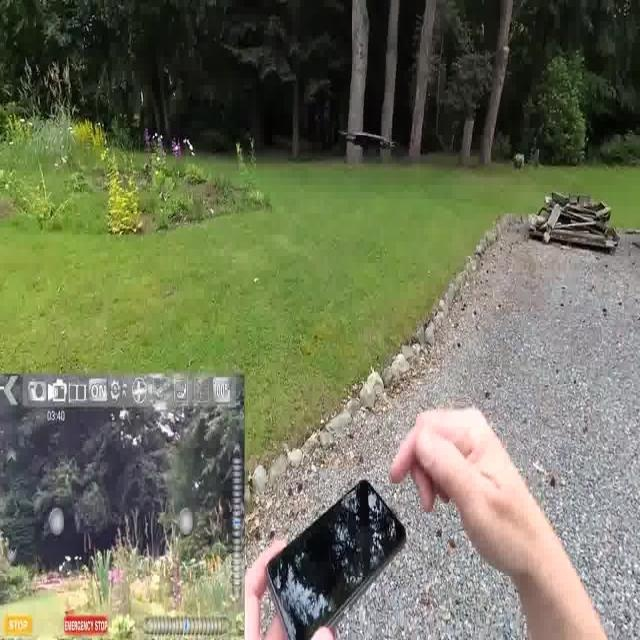

In [17]:
from ultralytics import YOLO
from PIL import Image
from IPython.display import display
import os

model = YOLO("/kaggle/input/datasets/garambharadhi/trained-model/train_results/weights/best.pt")

img_path = "/kaggle/input/datasets/garambharadhi/major-project/test/images/video19_2130_JPEG.rf.5f1423e034921ec46229c9ae5246407c.jpg"

results = model.predict(
    source=img_path,
    imgsz=832,
    conf=0.05,
    iou=0.45,
    max_det=3,
    device=0,
    save=True,
    save_txt=True,
    save_conf=True,
    show_labels=True,
    show_conf=True,
    project="/kaggle/working/results",
    name="img1_fix",
    exist_ok=True
)

print("Done")
out_img = "/kaggle/working/results/img1_fix/" + os.path.basename(img_path)
display(Image.open(out_img))


image 1/1 /kaggle/input/datasets/garambharadhi/major-project/test/images/video13143_JPEG.rf.f2b74b63ca77c3eae5bfdb3a21dd6c86.jpg: 832x832 (no detections), 25.2ms
Speed: 4.5ms preprocess, 25.2ms inference, 0.7ms postprocess per image at shape (1, 3, 832, 832)
Results saved to /kaggle/working/results/img2_fix
0 label saved to /kaggle/working/results/img2_fix/labels
Done


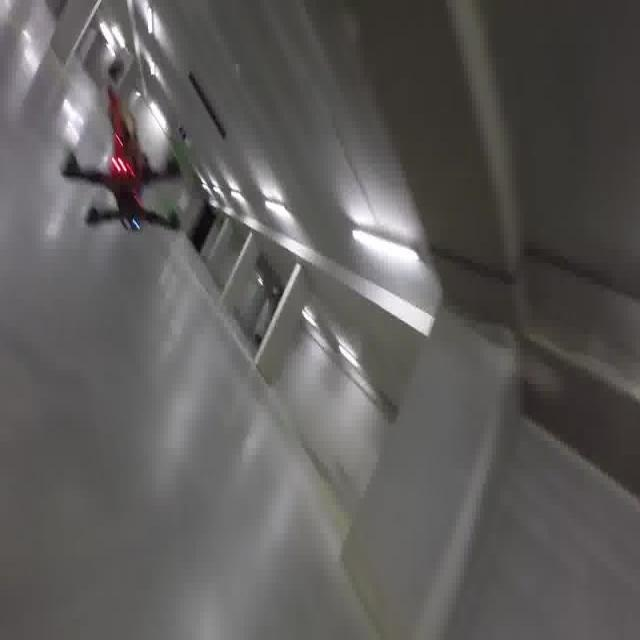

In [19]:
from ultralytics import YOLO
from PIL import Image
from IPython.display import display
import os

model = YOLO("//kaggle/input/datasets/garambharadhi/trained-model/train_results/weights/best.pt")

img_path = "/kaggle/input/datasets/garambharadhi/major-project/test/images/video13143_JPEG.rf.f2b74b63ca77c3eae5bfdb3a21dd6c86.jpg"

results = model.predict(
    source=img_path,
    imgsz=832,
    conf=0.70,
    iou=0.45,
    max_det=2,
    device=0,
    save=True,
    save_txt=True,
    save_conf=True,
    show_labels=True,
    show_conf=True,
    project="/kaggle/working/results",
    name="img2_fix",
    exist_ok=True
)

print("Done")
out_img = "/kaggle/working/results/img2_fix/" + os.path.basename(img_path)
display(Image.open(out_img))